In [55]:
import os
import glob
import urllib.request as r
import shutil
import ssl
import certifi


def data_yuklab_olish(saqlash_uchun_papka, data_nomi="salaries"):

    data_nomlari = [
        "salaries",
        "exams",
        "college",
        "cars",
        "mall",
        "uzbekistan_football",
        "humanitarian",
        "customer"
    ]

    assert data_nomi in data_nomlari, (
        f"Mavjud bo'lgan dataset {data_nomlari} dan birini kiriting!"
    )

    if data_nomi == "college":
        url = "https://drive.google.com/file/d/1vwfMpQ4ikAI91zn1bWxP_Iqz7DTFUA9F/view?usp=sharing"

    elif data_nomi == "salaries":
        url = "https://drive.google.com/file/d/1p-XtX29fgXT9CzBfpHm3t8r028gQPRhe/view?usp=sharing"

    elif data_nomi == "exams":
        url = "https://drive.google.com/file/d/1TYN_sRmauaDgNYgQ-0VSHVAJvLoxKx2R/view?usp=sharing"

    elif data_nomi == "cars":
        url = "https://drive.google.com/file/d/1Fi5IPdfEktnKyf3dyHmnh84a2jiXl33A/view?usp=sharing"

    elif data_nomi == "mall":
        url = "https://drive.google.com/file/d/1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm/view?usp=sharing"

    elif data_nomi == "uzbekistan_football":
        url = "https://drive.google.com/file/d/1eGWJVRNmGjfaH0o3dczBbNe_-RrW0_Jm/view?usp=sharing"

    elif data_nomi == "humanitarian":
        url = "https://drive.google.com/file/d/1dRv0-5iflumJFcjSHk-Vnjedtsn0WEEQ/view?usp=drive_link"

    elif data_nomi == "customer":
        url = "https://drive.google.com/file/d/1kW9UY7LI7kbnM5z2jgCMBUPUUMbsPe6p/view?usp=drive_link"


    # Fayl yo'lini yaratish
    full_path = f"{saqlash_uchun_papka}/{data_nomi}.zip"

    # Papkani yaratish
    os.makedirs(saqlash_uchun_papka, exist_ok=True)


    # Agar CSV allaqachon mavjud bo'lsa
    if os.path.isfile(f"{saqlash_uchun_papka}/{data_nomi}.csv"):

        print("Data yuklab olingan")

    else:

        print("Datani yuklash boshlanmoqda...")


        # Google Drive file ID ni olish
        file_id = url.split("/")[-2]

        # Google Drive download URL
        prefix = "https://drive.google.com/uc?/export=download&id="

        download_url = prefix + file_id


        # SSL certificate context
        ssl_context = ssl.create_default_context(
            cafile=certifi.where()
        )


        # Faylni yuklab olish
        with r.urlopen(download_url, context=ssl_context) as response:

            with open(full_path, "wb") as out_file:

                out_file.write(response.read())


        # ZIP faylni ochish
        shutil.unpack_archive(
            full_path,
            saqlash_uchun_papka
        )


        # ZIP faylni o'chirish
        os.remove(full_path)


        # Papkadagi fayllarni olish
        files = sorted(
            glob.glob(f"{saqlash_uchun_papka}/*"),
            key=os.path.getctime
        )


        # Oxirgi faylni olish
        fname = os.path.basename(files[-1])


        # CSV nomini o'zgartirish
        os.rename(
            f"{saqlash_uchun_papka}/{fname}",
            f"{saqlash_uchun_papka}/{data_nomi}.csv"
        )


        print(
            f"Data {saqlash_uchun_papka} papkasiga "
            f"{data_nomi} nomi bilan yuklab olindi."
        )

In [56]:
import pandas as pd
df = pd.read_csv(filepath_or_buffer="datasetlar/cars.csv")
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [57]:
ustun_nomlari = ["narx", "xizmat", "eshiklar", "o'rindiqlar", "bagaj", "xavfsizlik", "javob"]
df.columns = ustun_nomlari
df.head()

,narx,xizmat,eshiklar,o'rindiqlar,bagaj,xavfsizlik,javob
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [59]:
X = df.drop(["javob"], axis=1)
X.head()

,narx,xizmat,eshiklar,o'rindiqlar,bagaj,xavfsizlik
0,vhigh,vhigh,2,2,small,med
1,vhigh,vhigh,2,2,small,high
2,vhigh,vhigh,2,2,med,low
3,vhigh,vhigh,2,2,med,med
4,vhigh,vhigh,2,2,med,high


In [60]:
y = df["javob"]
y.head()

0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: javob, dtype: str

In [61]:
from sklearn.model_selection import train_test_split
# seed

X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2025) # split
X_test, X_valid, y_test, y_valid = train_test_split(X_validation, y_validation, test_size=0.5, random_state=2025) # split
len(X_train)

1381

In [62]:
X_test.head()

,narx,xizmat,eshiklar,o'rindiqlar,bagaj,xavfsizlik
544,high,high,2,2,med,high
1149,med,med,4,4,big,med
464,high,vhigh,3,2,big,low
1492,low,high,5more,2,big,high
1421,low,high,2,more,small,low


In [63]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder

In [64]:
encoder = OrdinalEncoder()
X_train = encoder.fit_transform(X_train)
X_valid = encoder.fit_transform(X_valid)
X_test = encoder.fit_transform(X_test)

In [65]:
# LinearRegression -> decision boundary is too simple
# time and accuracy tradeoff

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier() #
rfc.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [66]:
# Inference
acc_score = rfc.score(X_test, y_test) # acc score 0~1 * 100
print(f"Aniqlilik -> {(acc_score * 100):.2f}%")

Aniqlilik -> 99.42%


In [67]:
rfc.feature_importances_

array([0.19801409, 0.14835428, 0.06703705, 0.23621178, 0.08661861,
       0.26376418])

In [68]:
ustun_nomlari[:6]

['narx', 'xizmat', 'eshiklar', "o'rindiqlar", 'bagaj', 'xavfsizlik']

In [69]:
muhimlik_darajalari = pd.Series(rfc.feature_importances_, index = ustun_nomlari[:6]).sort_values(ascending = False)
muhimlik_darajalari

xavfsizlik     0.263764
o'rindiqlar    0.236212
narx           0.198014
xizmat         0.148354
bagaj          0.086619
eshiklar       0.067037
dtype: float64

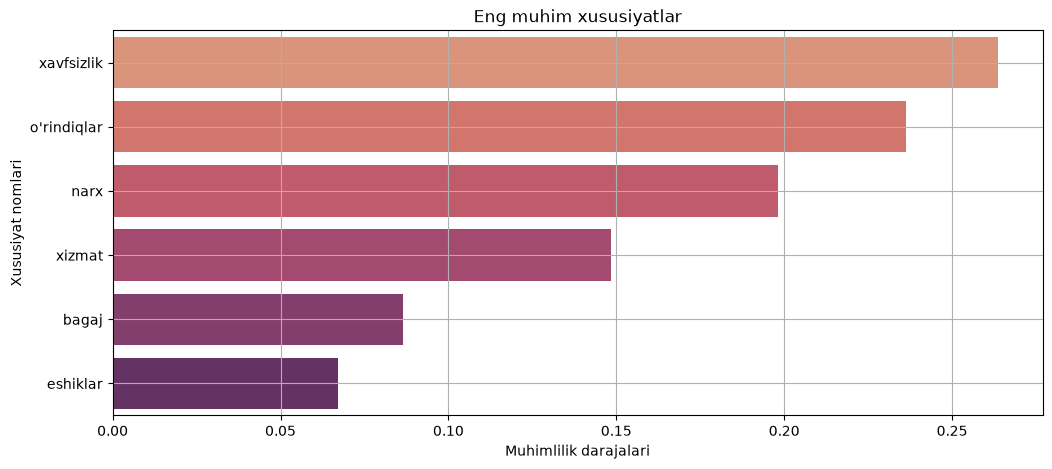

In [70]:
from matplotlib import pyplot as plt
# !pip install seaborn
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.barplot(x = muhimlik_darajalari, y = muhimlik_darajalari.index, hue = muhimlik_darajalari.index, palette = "flare")
plt.xlabel("Muhimlilik darajalari")
plt.ylabel("Xususiyat nomlari")
plt.title("Eng muhim xususiyatlar")
plt.grid()

In [ ]:
x1,x2, y1,y2
# euclidean distance
# KMeans clustering algorithm (unsupervised)
# KNearest Neighbor clustering algorithm (supervised)

# Unsupervised Learning

In [17]:
# 100 ta tosh bu toshlarni deylik kattaligi, rangiga qilib ajrat desa bu supervised bulardi.
# lebel bulmaydi uzi harakat qiladi bizga berilgan featurelarga qarab.
# lekin toshlarni berib ajrat desa bu unsupervised toshlarni xususiyatiga qarab turib tug'ri deb bilgan featurelarni ajratadi.


In [71]:
data_yuklab_olish(saqlash_uchun_papka="datasetlar", data_nomi="mall")

Datani yuklash boshlanmoqda...
Data datasetlar papkasiga mall nomi bilan yuklab olindi.


In [72]:
import pandas as pd
df = pd.read_csv(filepath_or_buffer="datasetlar/mall.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [73]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [74]:
1

1

In [75]:
0.22222222

0.22222222

In [76]:
df.info()
# int64 int32; int16 
# float64; float32; float16 
# time(memory)-accuracy tradeoff

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [77]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [78]:
len(df)

200

In [79]:
# eni (qator) -> 0; bo'yi (ustun) -> 1
df.iloc[2, 2:4] # : bu belgi barcha indeksni olib keladi. 

Age                   20
Annual Income (k$)    16
Name: 2, dtype: object

In [80]:
X = df.iloc[:, [3, 4]]
X = X.values

In [81]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [82]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


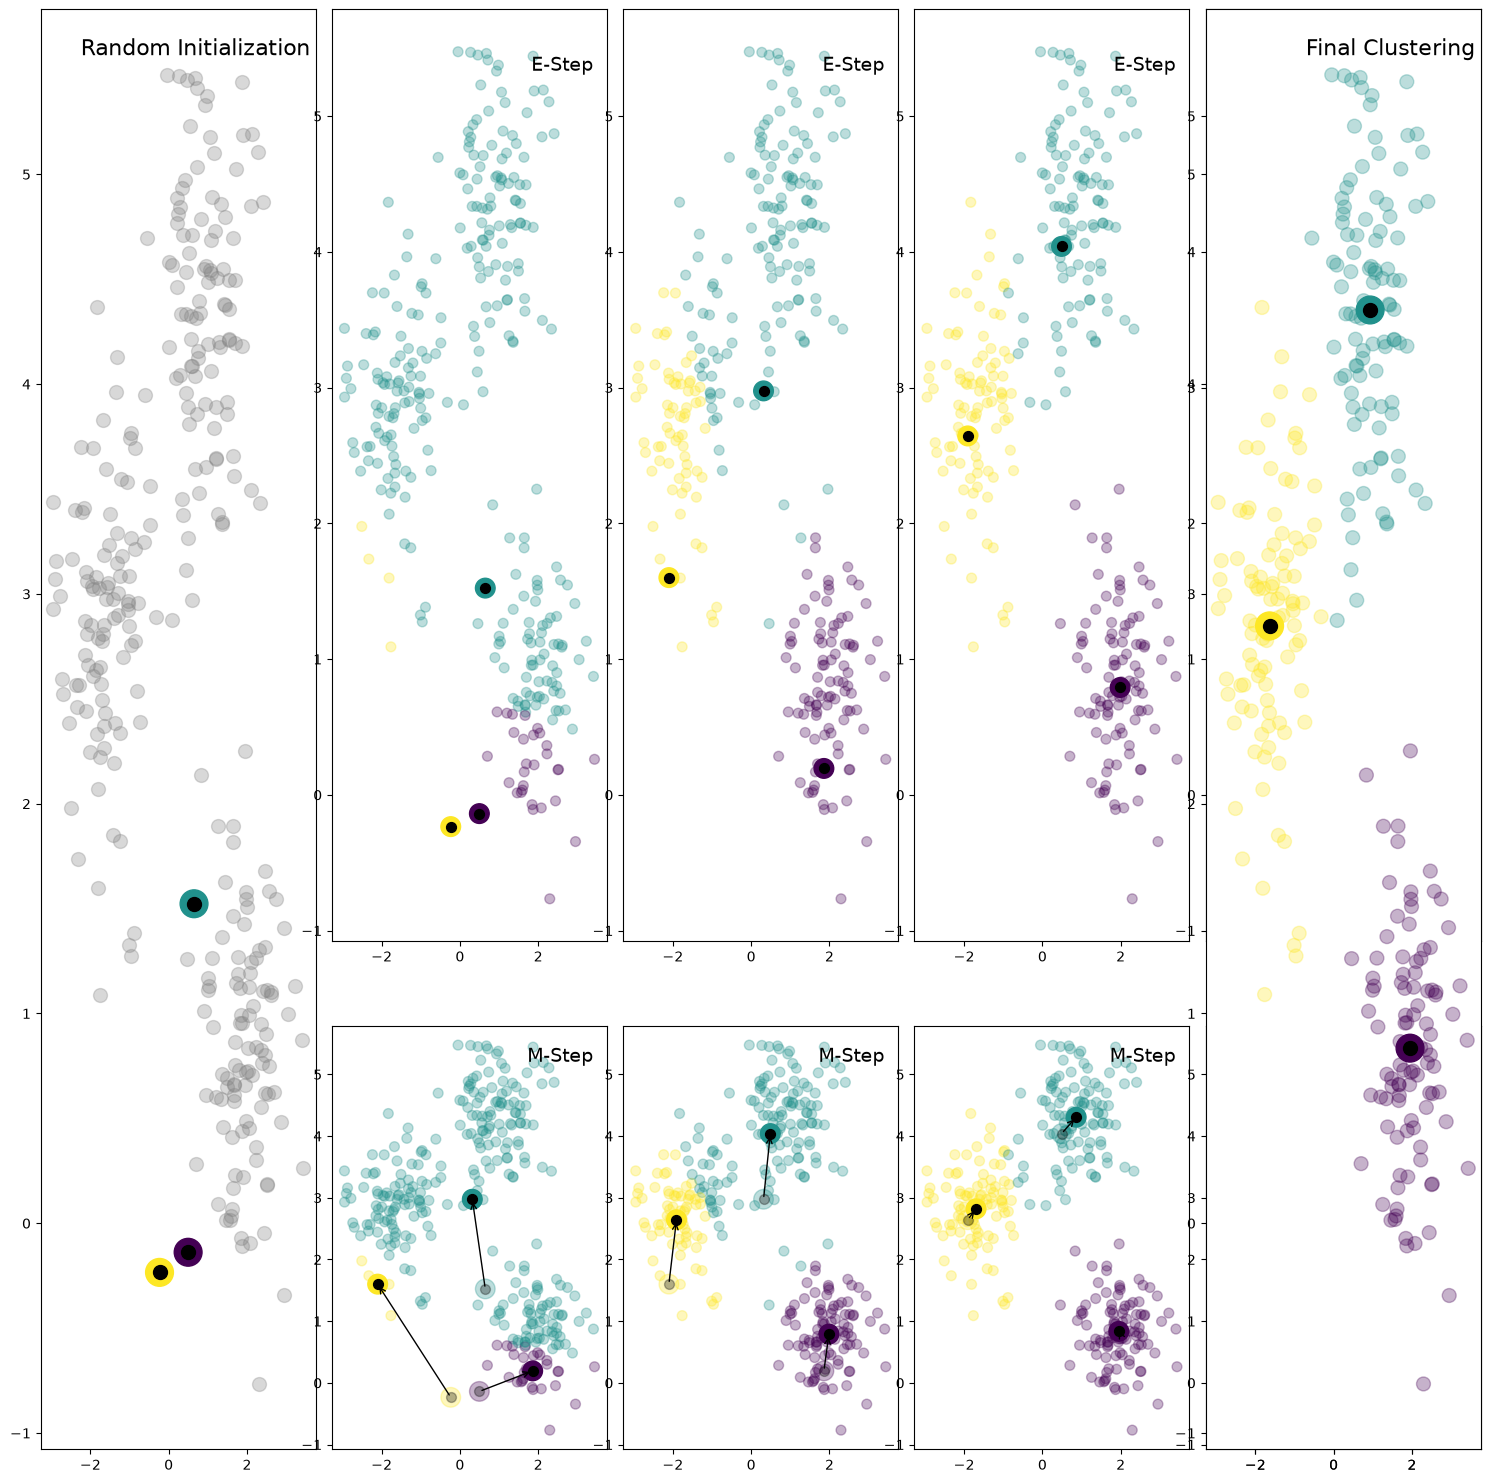

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances_argmin

# Number of clusters and iterations
clusters = 3
iterations = 4

# Generate synthetic data
data, y_true = make_blobs(n_samples=300, centers=clusters, cluster_std=0.60, random_state=0)
rng = np.random.RandomState(42)
centers = rng.randn(clusters, 2)

def draw_points(ax, c, factor=1):
    if isinstance(c, str) or len(c) != len(data):  # Ensure 'c' matches the data length
        # Default color for invalid or string 'c'
        ax.scatter(data[:, 0], data[:, 1], color=c, s=50 * factor, alpha=0.3)
    else:
        # Numeric values for colormap
        ax.scatter(data[:, 0], data[:, 1], c=c, cmap='viridis', s=50 * factor, alpha=0.3)

def draw_centers(ax, centers, factor=1, alpha=1.0):
    ax.scatter(centers[:, 0], centers[:, 1], c=np.arange(len(centers)), cmap='viridis', s=200 * factor, alpha=alpha)
    ax.scatter(centers[:, 0], centers[:, 1], c='black', s=50 * factor, alpha=alpha)

# Set up the grid layout dynamically
fig = plt.figure(figsize=(15, 4 * iterations))
num_cols = max(3 + 3 * iterations, 3)  # Ensure enough columns
gs = plt.GridSpec(3, num_cols, left=0.02, right=0.98, bottom=0.05, top=0.95, wspace=0.2, hspace=0.2)

# Random initialization
ax0 = fig.add_subplot(gs[:, :3])
ax0.text(0.98, 0.98, "Random Initialization", transform=ax0.transAxes, ha='right', va='top', size=16)
draw_points(ax0, 'gray', factor=2)
draw_centers(ax0, centers, factor=2)

# KMeans iterations
for i in range(iterations):
    start_col = 3 + 3 * i
    end_col = 3 + 3 * (i + 1)

    if end_col > num_cols:
        raise ValueError("GridSpec layout does not have enough columns for all iterations.")

    ax1 = fig.add_subplot(gs[:2, start_col:end_col])
    ax2 = fig.add_subplot(gs[2:, start_col:end_col])

    # E-step: Assign each point to the nearest cluster center
    y_pred = pairwise_distances_argmin(data, centers)
    draw_points(ax1, y_pred, factor=1)
    draw_centers(ax1, centers, alpha=1)

    # M-step: Recalculate cluster centers
    new_centers = np.array([
        data[y_pred == j].mean(0) if np.any(y_pred == j) else centers[j]
        for j in range(clusters)
    ])
    draw_points(ax2, y_pred, factor=1)
    draw_centers(ax2, centers, alpha=0.3)
    draw_centers(ax2, new_centers, alpha=1)

    for j in range(clusters):
        ax2.annotate('', new_centers[j], centers[j], arrowprops=dict(arrowstyle='->', linewidth=1))

    centers = new_centers

    ax1.text(0.95, 0.95, "E-Step", transform=ax1.transAxes, ha='right', va='top', size=14)
    ax2.text(0.95, 0.95, "M-Step", transform=ax2.transAxes, ha='right', va='top', size=14)

# Final E-step
y_pred = pairwise_distances_argmin(data, centers)
ax_final = fig.add_subplot(gs[:, -3:])
draw_points(ax_final, y_pred, factor=2)
draw_centers(ax_final, centers, factor=2)
ax_final.text(0.98, 0.98, "Final Clustering", transform=ax_final.transAxes, ha='right', va='top', size=16)

plt.show()

In [84]:
inertias = []

n_clusters = [i for i in range(2, 11)] # 2~10
for idx, n in enumerate(n_clusters):
    # if idx == 1: break
    kmeans = KMeans(n_clusters=n)
    kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)

In [85]:
inertias

[184131.88502788506,
 106348.37306211122,
 73679.78903948836,
 44454.476479679724,
 37271.88623658949,
 36670.108442415425,
 25029.25342493587,
 27043.768483996162,
 21285.192500842597]

# Elbow method

In [ ]:
# objective of clustering algorithms increase interclass variance, increase intraclass variance
# klasslar orasida increaseni kattalashtirish, lekin klass ichidagi increaseni kamaytirish.

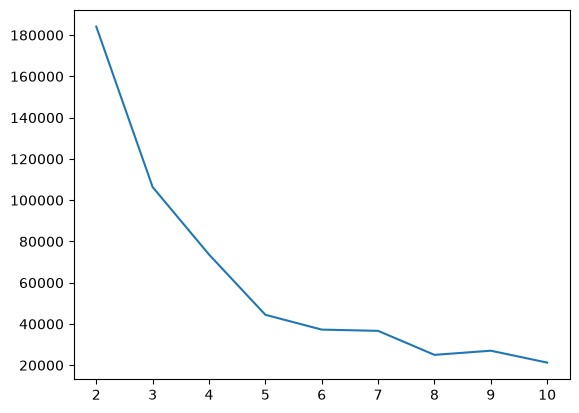

In [86]:
plt.plot(range(2, 11), inertias)
# plt.xlabel

In [87]:
kmeans = KMeans(n_clusters = 3)
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [88]:
javoblar = kmeans.fit_predict(X)
np.unique(javoblar)

array([0, 1, 2], dtype=int32)

In [89]:
javoblar

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int32)

# Pseudo-labeling

In [90]:
X[113]

array([64, 46])

In [91]:
print(javoblar == 1)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

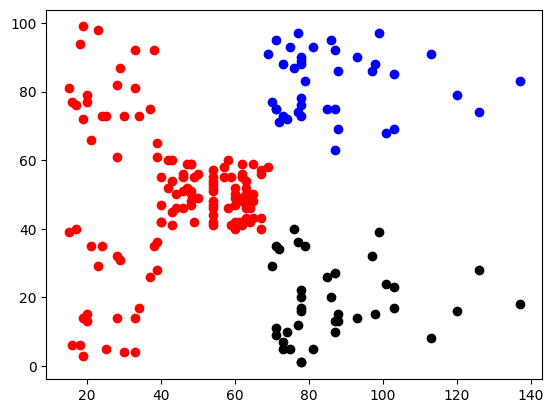

In [96]:
plt.scatter(x = X[javoblar == 0, 0], y = X[javoblar == 0 , 1], color = "blue" )
plt.scatter(x = X[javoblar == 1, 0], y = X[javoblar == 1 , 1], color = "red" )
plt.scatter(x = X[javoblar == 2, 0], y = X[javoblar == 2 , 1], color = "black" )
# plt.scatter(x = X[javoblar == 3, 0], y = X[javoblar == 3 , 1], color = "yellow" )
# plt.scatter(x = X[javoblar == 4, 0], y = X[javoblar == 4 , 1], color = "green" )

In [92]:
df["javoblar"] = javoblar

In [93]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),javoblar
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [94]:
X = df.drop(["javoblar"], axis = 1)
X

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [95]:
y = df["javoblar"]
y

0      1
1      1
2      1
3      1
4      1
      ..
195    0
196    2
197    0
198    2
199    0
Name: javoblar, Length: 200, dtype: int32

In [ ]:
# AI -> ML -> DL: data ham murakkab; 
# porject : data increase; model increase
# DL: 1) image processing (video); 2) text (RNN, GRLSTM, transformer, LLM)